<img src="./img/uomlogo.png" align="left"/><br><br>
# PHYS20762 - Project - Measuring Drop Spreading Law

Assignment by 
Draga Pihler-Puzovic<br>
University of Manchester  
January 2021

Tasks completed by 
11301011
February 2025

We first initialise our Python interpreter

In [10]:
# Initialisation
import string
from math import *
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import random

plt.rcParams.update({'font.size': 14})
plt.style.use('default')

##  Background

The spreading law quantifies the spread of a liquid over a surface by considering surface tensions across each bondary of the medium. It begins through considering the spreading parameter S, where

$$
S = \gamma_s - (\gamma_{SL} + \gamma_L), 
$$ 

in which gamma_S is the surface tension of the solid, gamma_SL is the tension between the solid and the liquid, and gamma_L is the surface tension of the liquid. 

This can be specified to the Spherical Cap Volume formula, which is to consider the evolution of the volume of a liquid forming a spherical cap shape. This is governed by the relation 
$$
\left(\frac{\pi}{6}\right) H \left(3R^2 + H^2\right) - V. 
$$


To identify the motion in the spread of this liquid, two laws exist which depict the relationship between the contact angle and the spreading speed of the droplet. These are the _de Gennes_ law and the _Cox-Voinov_ law, which were formulated in the 1980s which follow two different approaches. The de Gennes law posits that molecular interactions at the contact line affect how the droplet may spread [1]. Meanwhile, the Cox-Voinov law extended this to include hydrodynamic flow, which details how the contact angle may be dynamic rather than fixed [2]. The details on numerically approaching both methods will be expanded below. 

In this experiment, three datasets for the radius of the volume was given. This will be used to numerically obtain the height, which is the solution to the cubic equation above. Through this, the angle formed by the droplet will be obtained. Then, the relationship between the angle formed by the droplet and the speed of droplet spread will be plotted, and each of the two laws will be fitted onto the plot. By obtaining the Chi-Squared statistic for each of the fits, the suitability of each law will be compared to ultimately determine which law suits the dataset more.


[1] P.-G. de Gennes, *Wetting: Statics and Dynamics*, Rev. Mod. Phys. **57**, 827 (1985). [DOI: 10.1103/RevModPhys.57.827](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.57.827)

[2] R.G. Cox, *The Dynamics of the Spreading of Liquids on a Solid Surface*, J. Fluid Mech. **168**, 169 (1986). [PDF](https://people.maths.bris.ac.uk/~majge/coxvoinov_theory_with_slip.pdf)

## Defining Constants and Functions

In [11]:
#Constants and Functions
V = 7.6e-15  # The volume in cubic meters upon conversion but was originally 7.6 picolitres

def height_equation(H, R, V):
    return (np.pi / 6) * H * (3 * R**2 + H**2) - V

![](./img/bee.png)
## Experimental Data with Error Bars

This is data that we are working with. It consists of a sequence of circle radii ($R$, measured in micrometers), obtained from image processing in three different experimental runs. The corresponding time ($t$, measured in seconds) was obtained from the image timestamps measured from the beginning of the experiment.     

The error for the radius is taken as the standard deviation of the radius dataset.

In [12]:
# Radius data 
# experiment 1
radius_data1 = np.array([59.513027, 66.368389, 69.506166, 71.700852, 74.735925, 76.007795, 76.695256, 78.039551, 79.598386, 80.075493, 80.079624, 81.495363, 82.598934, 83.172805, 84.919440, 85.155809, 85.718415, 85.920147, 86.000243, 87.120934, 87.507943, 87.786892, 87.060409, 88.086562, 88.113767, 88.436448, 89.082172, 89.139957, 89.210538, 89.356928, 90.312937, 90.406557, 90.754907, 90.88941, 91.096467])*1e-06
# experiment 2
radius_data2 = np.array([59.810888, 65.360919, 69.088934, 72.594631, 74.694093, 76.440186, 78.133942, 78.618537, 79.753566, 80.745559, 81.422723, 81.634563, 82.861597, 84.335873, 85.362055, 85.537714, 86.159399, 86.873675, 86.918131, 87.003533, 87.126402, 87.155440, 87.224911, 87.394479, 87.433936, 87.626938, 87.701465, 87.834029, 87.963874, 88.153147, 88.209880, 88.542036, 88.86527, 89.082038, 89.214132])*1e-06
#experiment 3
radius_data3 = np.array([58.200029, 64.826353, 69.332991, 73.504694, 74.295033, 77.506575, 78.413291, 79.952682, 81.339708, 81.938359, 82.528196, 82.807452, 83.378999, 84.521468, 84.507216, 85.064265, 85.247146, 85.900079, 86.475709, 86.776052, 87.158810, 87.343755, 87.448085, 87.822712, 88.140434, 88.311032, 88.619312, 88.970210, 89.373613, 89.754486, 89.900430, 90.116608, 90.288358, 90.711677, 90.989783])*1e-06
# time
time = np.array([0.500000, 1.000000, 1.500000, 2.000000, 2.500000, 3.000000, 3.500000, 4.000000, 4.500000, 5.000000, 5.500000, 6.000000, 6.500000, 7.000000, 7.500000, 8.000000, 8.500000, 9.000000, 9.500000, 10.000000, 10.500000, 11.000000, 11.500000, 12.000000, 12.500000, 13.000000, 13.500000, 14.000000, 14.500000, 15.000000, 15.500000, 16.000000, 16.500000, 17.000000, 17.500000])

#Calculating Error for radius
radius_data = np.array([radius_data1, radius_data2, radius_data3])
radius_mean = (radius_data1 + radius_data2 + radius_data3)/3

#Defining error as the standard deviation of the three radii and saving it across all steps
std_radius = np.std(radius_data, axis=0)  


The average radius is plotted below. The raw data is also plotted.

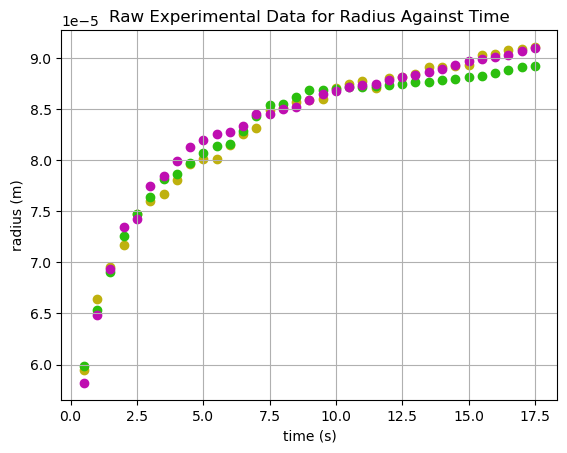

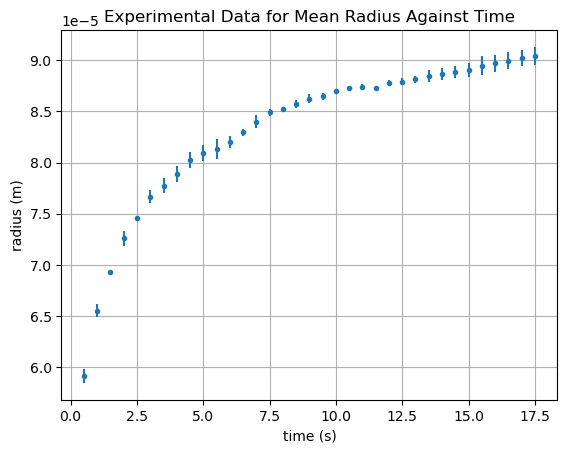

In [13]:
#Plotting the mean radius with error

plt.scatter(time, radius_data1, marker="o", color = "#bfb10e")
plt.scatter(time, radius_data2, marker="o", color = "#2bbf0e")
plt.scatter(time, radius_data3, marker="o", color = "#bf0eb1")
# labelling axis and title
plt.xlabel("time (s)")
plt.ylabel("radius (m)")
plt.title("Raw Experimental Data for Radius Against Time")
plt.grid()
plt.show()

plt.errorbar(time, radius_mean, yerr=std_radius, fmt='.')
plt.xlabel("time (s)")
plt.ylabel("radius (m)")
plt.title("Experimental Data for Mean Radius Against Time")
plt.grid()
plt.show()

![](./img/bee.png)
## Extracting Quantities Using Experimental Data

In order to find the spreading law: a relationship between the speed of the contact line ($U$) and the contact angle ($\theta$), we need to first find the quantities themselves, ie express $U$ and $\theta$ using $R=R(t)$. 

To speed of the contact line can be calculated using $U = \frac{dR}{dt} \approx \frac{R(t+\delta t)-R(t)}{\delta t}$, where $R(t+\delta t)$ and $R(t)$ are two sequential values of the footprint radii measured with time intreval $\delta t$ apart.  

__To do so, the difference in each value within the array was calculated to numerically obtain the change in distance. This was divided by the time intervals. The error was again calculated through the standard deviations of the change in speeds.__ 

To find the contact angle, we make the spherical cap approximation that allows us to calculate the height of the drop ($H$) from its volume ($V=7.6$ pL) and its footprint radius ($R$) which are known from experiments via relationship $V=\frac{\pi}{6}H(3R^2+H^2)$. The contact angle can then be found from $R$ and $H$ using $\theta = \frac{\pi}{2} - \mathrm{atan}\frac{R^2-H^2}{2HR}$. 

__This was calculated through the fsolve function and approximating a solution to the relationship.__

There are three sets of experimental data, so for each one of them a relationship $U=U(\theta)$ should be found.

In [15]:
# calculating the change in radii
delta_radius1 = np.diff(radius_data1)
delta_radius2 = np.diff(radius_data2)
delta_radius3 = np.diff(radius_data3)
delta_radius_mean = np.diff(radius_mean)
delta_t = np.diff(time)
R = radius_mean
#calculating speeds, where speed is the average
speed_mean = np.array(delta_radius_mean / delta_t)
speed_1 = np.array(delta_radius1 / delta_t)
speed_2 = np.array(delta_radius2 / delta_t)
speed_3 = np.array(delta_radius3 / delta_t)
speed_error = (std_radius[:-1] / delta_t) 

#Calculate H and Theta from Mean of Radii
H_solutions = np.array([fsolve(height_equation, 1.0, args=(r, V))[0] for r in R])
theta = np.pi/2 - np.arctan((radius_mean**2-H_solutions**2) / (2*radius_mean*H_solutions))

#Calculating Theta 1
H_solutions_1 = np.array([fsolve(height_equation, 1.0, args=(r, V))[0] for r in radius_data1])
theta_1 = np.pi/2 - np.arctan((radius_data1**2-H_solutions_1**2) / (2*radius_data1*H_solutions_1))

#Calculating Theta 2
H_solutions_2 = np.array([fsolve(height_equation, 1.0, args=(r, V))[0] for r in radius_data2])
theta_2 = np.pi/2 - np.arctan((radius_data2**2-H_solutions_2**2) / (2*radius_data2*H_solutions_2))

#Calculating Theta 3
H_solutions_3 = np.array([fsolve(height_equation, 1.0, args=(r, V))[0] for r in radius_data3])
theta_3 = np.pi/2 - np.arctan((radius_data3**2-H_solutions_3**2) / (2*radius_data3*H_solutions_3))

#Calculating error in theta
theta_error = np.std(np.array([theta_1, theta_2, theta_3]), axis=0)

The average speed against time and average contact angle against time are plotted below. 

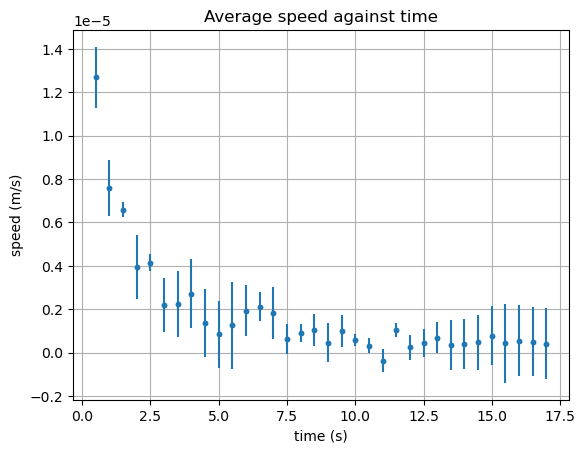

In [16]:
plt.scatter(time[:-1], speed_mean, marker = ".")
plt.errorbar(time[:-1], speed_mean, yerr=speed_error, fmt=".")
plt.xlabel('time (s)')
plt.ylabel('speed (m/s)')
plt.title('Average speed against time')
plt.grid()
plt.show()

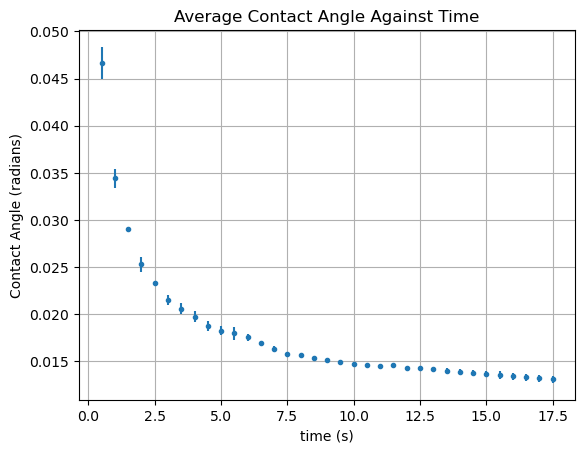

In [17]:
#Error for contact angle, change to radians
plt.errorbar(time, theta, yerr=theta_error, fmt='.')
plt.ylabel('Contact Angle (radians)')
plt.xlabel('time (s)')
plt.title('Average Contact Angle Against Time')
plt.grid()
plt.show()

The data $U=U(\theta)$ obtained for each of the three experimental runs is used to estimate the relationship between the mean contact line speed and the mean contact angle, and the corresponding errors on those. The result of this is plotted below. 

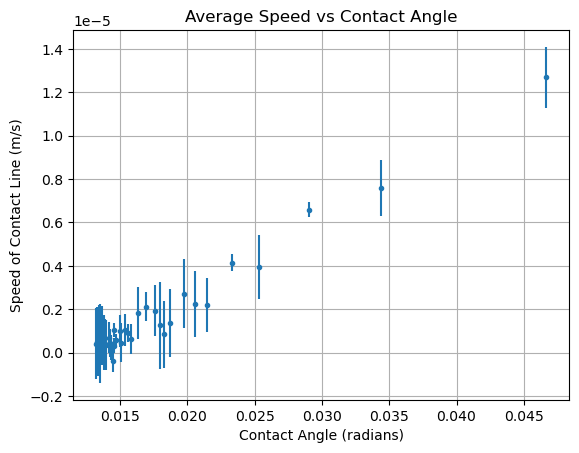

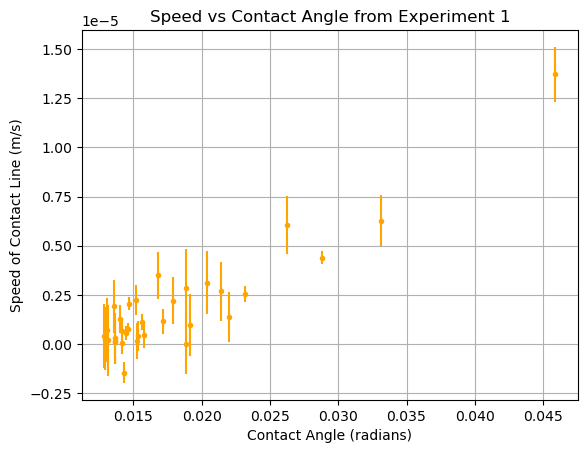

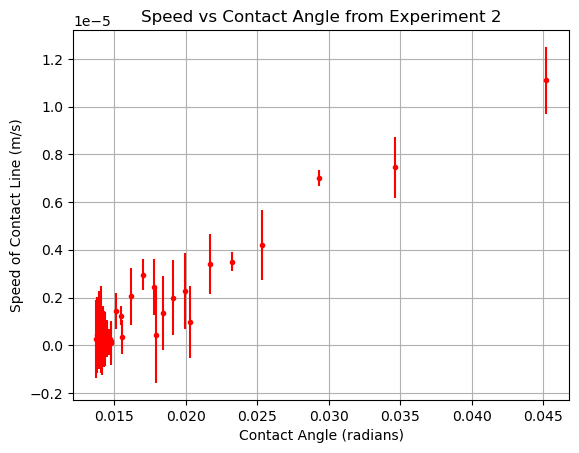

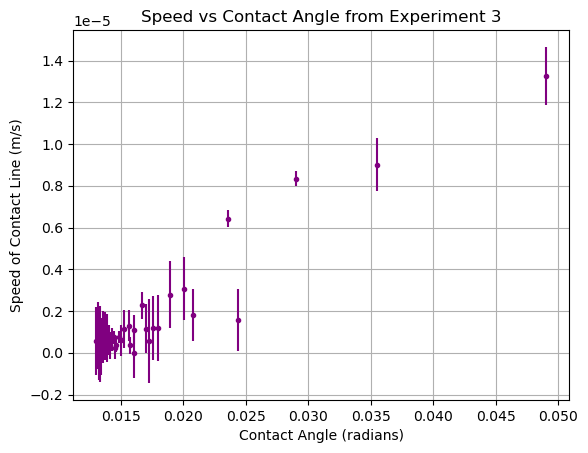

In [22]:
# write your code here

plt.errorbar(theta[:-1], speed_mean,  yerr=speed_error, fmt='.')
plt.xlabel('Contact Angle (radians)')
plt.ylabel('Speed of Contact Line (m/s)')
plt.title('Average Speed vs Contact Angle')
plt.grid()
plt.show()

plt.errorbar(theta_1[:-1], speed_1, yerr=speed_error, fmt='.', color = 'orange')
plt.xlabel('Contact Angle (radians)')
plt.ylabel('Speed of Contact Line (m/s)')
plt.title('Speed vs Contact Angle from Experiment 1')
plt.grid()
plt.show()

plt.errorbar(theta_2[:-1], speed_2, yerr=speed_error, fmt='.', color = 'red')
plt.xlabel('Contact Angle (radians)')
plt.ylabel('Speed of Contact Line (m/s)')
plt.title('Speed vs Contact Angle from Experiment 2')
plt.grid()
plt.show()

plt.errorbar(theta_3[:-1], speed_3, yerr=speed_error, fmt='.', color = 'purple')
plt.xlabel('Contact Angle (radians)')
plt.ylabel('Speed of Contact Line (m/s)')
plt.title('Speed vs Contact Angle from Experiment 3')
plt.grid()
plt.show()

![](./img/bee.png)
## Fitting Spreading Laws - de Gennes Law

We will now attemp to fit the Cox-Voinov law ($U = U_0( \theta^3 –  \theta_0^3)$) and the de Gennes law ($U = U_0( \theta^2 –  \theta_0^2)$) to the mean data $U=U(\theta)$ ploted above, where $U_0$ is termed the characteristic speed of the contact line, and $\theta_0$ is the equilibrium contact angle (when $\theta=\theta_0$, $U=0$). To avoid using nonlinear least square method, we will fit a straight line to the data $U=U(\theta^2)$ and $U=U(\theta^3)$. This will produce the values for the characteristic speed and the error on it $U_0^{fit} \pm \delta U_0^{fit}$, but it will not give the values of the equilibrium contact angle $\theta_0^{fit}$. Instead, $[U_0\theta^n]^{fit}$ with $n=2$ or $n=3$ will be found, from which $\theta_0$ can be comupted. The corresponding error $\delta\theta^{fit}$ should be found by propagating the errors from  $[U_0\theta^n]^{fit}$ and $U_0^{fit}$.

#### The de Gennes law will be attempted first.

In [23]:
theta_squared = theta[:-1] ** 2
x = theta_squared

# Perform a linear fit and get the errors
fit_parameters, fit_errors = np.polyfit(theta_squared,speed_mean,1,cov=True)
fit_m = fit_parameters[0] #This is the gradient of the fit
fit_c = fit_parameters[1] #This is the intercept of the fit

U_0 = fit_m
theta_0 = np.sqrt(-fit_c / U_0)
U_0_error = sigma_m
theta_0_error = 0.5*(sigma_c)

# Here, we (rather laboriously) explicitly define some variables so you can see 
# exactly which matrix element is which
variance_m = fit_errors[0][0]
variance_c = fit_errors[1][1]
sigma_m = np.sqrt(variance_m)
sigma_c = np.sqrt(variance_c)
print('Linear np.polyfit of y = m*x + c')
print('Gradient  m = {:04.10f} +/- {:04.10f}'.format(fit_m,sigma_m))
print('Intercept c = {:04.10f} +/- {:04.10f}'.format(fit_c,sigma_c))
print(f'Characteristic speed: {U_0:0.10f} ± {U_0_error:0.10f} m/s')
print(f'Equilibrium Angle: {theta_0:0.10f} ± {theta_0_error:0.10f} radians')

H_error = np.sqrt((radius_mean[:-1]*sigma_m)**2 + (fit_m*speed_error)**2)


NameError: name 'sigma_m' is not defined

This gradient and intercept is achieved through the code above, which allows the calculation of the characteristic speed and the equilibrium contact angle. 

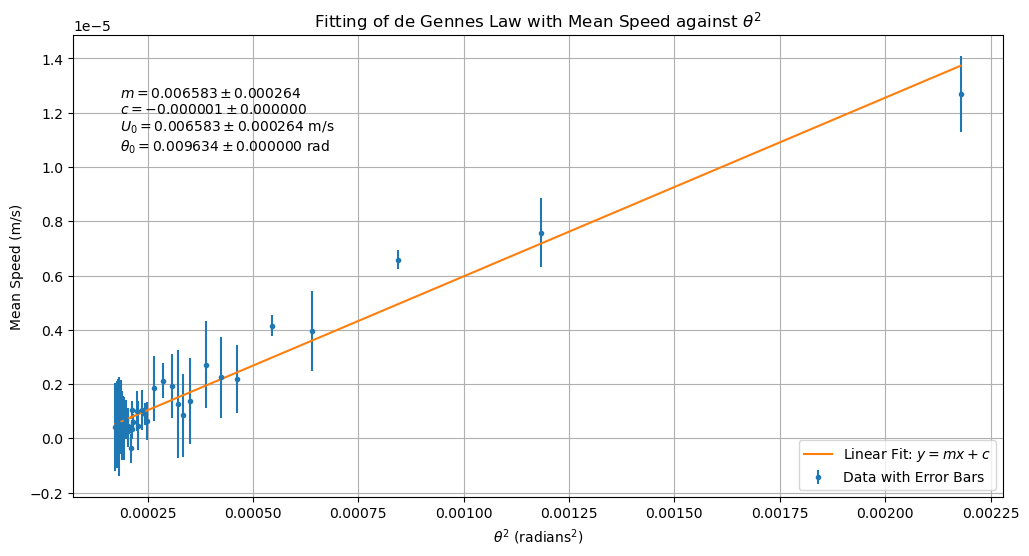

In [208]:
#Plotting the data and the fit 
plt.rcParams["figure.figsize"] = (12, 6)
plt.figure()
plt.errorbar(theta_squared, speed_mean, yerr=speed_error, fmt='.', label="Data with Error Bars") 
plt.plot(theta_squared, fit_m*x + fit_c, label=r"Linear Fit: $y = mx + c$")

#Displaying values obtained from the fit and numerical calculations
textstr = (
    r"$m = {:.6f} \pm {:.6f}$" "\n"
    r"$c = {:.6f} \pm {:.6f}$" "\n"
    r"$U_0 = {:.6f} \pm {:.6f}$ m/s" "\n"
    r"$\theta_0 = {:.6f} \pm {:.6f}$ rad"
).format(fit_m, sigma_m, fit_c, sigma_c, U_0, U_0_error, theta_0, theta_0_error)

plt.annotate(textstr, xy=(0.05, 0.75), xycoords='axes fraction', fontsize=10)

# Labels and title
plt.xlabel(r"$\theta^2$ ($\mathrm{radians}^2$)")
plt.ylabel("Mean Speed (m/s)")
plt.title(r"Fitting of de Gennes Law with Mean Speed against $\theta^2$")
plt.legend()
plt.grid()

plt.show()

![](./img/bee.png)
## Chi-squared Test for de Gennes law

To establish which of the two laws better fits the data, we conduct the chi-squared test. The case is further strengthened using the residual plots. 

The Chi-squared test is a measure of the goodness of fit of the data to its model. It calculates the distance between each point and its corresponding location on the line of best fit, which is known as the residual. This value is summed across all of the points, indicating how far off the points lie from the model. To determine whether the fit is consistent or not, the reduced Chi-squared value is taken, where the chi squared value is divided by the number of points, while deducting the number of parameters available for adjusting. If the reduceed chi-squared value lies between 0.5 and 2, it signifies a statistically significant fit. 

The residual plot is also a significant measure, since it can show how far the distances between the point and the fit may deviate. The residual is ideally randomly distributed near values of 0 to show the model does fit the data, and this will be seen below. 

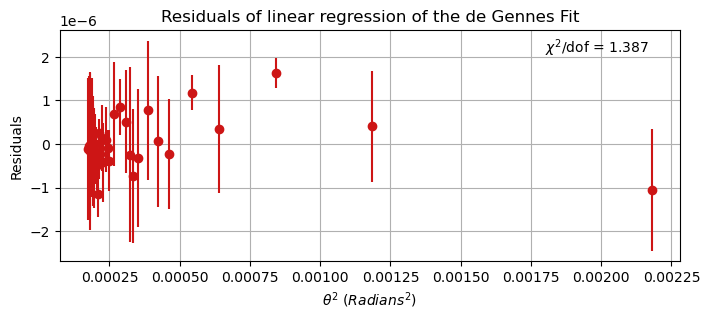

Chi-Squared Value: 44.39328738979809
Reduced Chi-Squared: 1.3872902309311903


In [209]:
y = speed_mean

# Perform fit using np.polyfit
fit_parameters, fit_errors = np.polyfit(x,y,1,cov=True)
# Create set of fitted y values using fit parameters from np.polyfit, and original x values
y_fitted = np.polyval(fit_parameters,x)

# Defining errors and weights
y_sigma = speed_error
y_weights = (1/y_sigma)*np.ones(np.size(y))

# Create array of error values for the error bar plot below; each element is y_sigma
y_errors = y_sigma*np.ones(np.size(y))

# Make plot of the residuals
plt.rcParams["figure.figsize"] = (8,3)
plt.figure()
plt.errorbar(x, y-y_fitted,yerr=y_errors, fmt='o', color = "#cd1515")
plt.xlabel(r"$\theta^2$ ($Radians^2$)")
plt.ylabel("Residuals")
plt.title("Residuals of linear regression of the de Gennes Fit")

textstr = r"$\chi^2$/dof = ${:.3f}$".format(chi_squared_reduced)

plt.annotate(textstr, xy=(0.95, 0.90), xycoords='axes fraction', fontsize=10,
             ha='right')
 
plt.grid()
plt.show()

chi_squared = np.sum(((y - y_fitted) / y_sigma) ** 2)

# Calculating Chi Squared Fit
print(f"Chi-Squared Value: {chi_squared}")
dof = len(y) - len(fit_parameters)
chi_squared_reduced = chi_squared / dof
print(f"Reduced Chi-Squared: {chi_squared_reduced}")

_Thus, the de Gennes law fitted onto this dataset gives a reduced Chi Squared value of 1.387, showing that the fit is suitable for the data._
Next, the Cox-Voinov law will be fitted onto the data, and the procedure will be repeated. 

## Fitting Cox-Voinov Law

In [210]:
theta_cubed = theta[:-1] ** 3
x_cv = theta_cubed  # All variables will have the label 'cv' to avoid overwriting the values from de Gennes fit. 

# Perform a linear fit and get the errors
fit_parameters_cv, fit_errors_cv = np.polyfit(theta_cubed, speed_mean, 1, cov=True)
fit_m_cv = fit_parameters_cv[0]
fit_c_cv = fit_parameters_cv[1]

# Obtaining the characterstic speed and equilibrium angle
U_0_cv = fit_m_cv
theta_0_cv = np.sqrt(fit_c_cv / U_0_cv)
U_0_error_cv = sigma_m
theta_0_error_cv = 0.5 * (sigma_c)

# Uncertainty calculations
variance_m_cv = fit_errors_cv[0][0]
variance_c_cv = fit_errors_cv[1][1]
sigma_m_cv = np.sqrt(variance_m_cv)
sigma_c_cv = np.sqrt(variance_c_cv)

# Printing useful values
print('Linear np.polyfit of y = m*x + c')
print('Gradient  m = {:04.10f} +/- {:04.10f}'.format(fit_m_cv, sigma_m_cv))
print('Intercept c = {:04.10f} +/- {:04.10f}'.format(fit_c_cv, sigma_c_cv))

print(f'Characteristic speed: {U_0_cv:0.10f} ± {U_0_error_cv:0.10f} m/s')
print(f'Equilibrium Angle: {theta_0_cv:0.10f} ± {theta_0_error_cv:0.10f} radians')

H_error_cv = np.sqrt((radius_mean[:-1] * sigma_m_cv) ** 2 + (fit_m_cv * speed_error) ** 2)


Linear np.polyfit of y = m*x + c
Gradient  m = 0.1348214447 +/- 0.0087049943
Intercept c = 0.0000005912 +/- 0.0000001743
Characteristic speed: 0.1348214447 ± 0.0002640293 m/s
Equilibrium Angle: 0.0020941324 ± 0.0000000700 radians


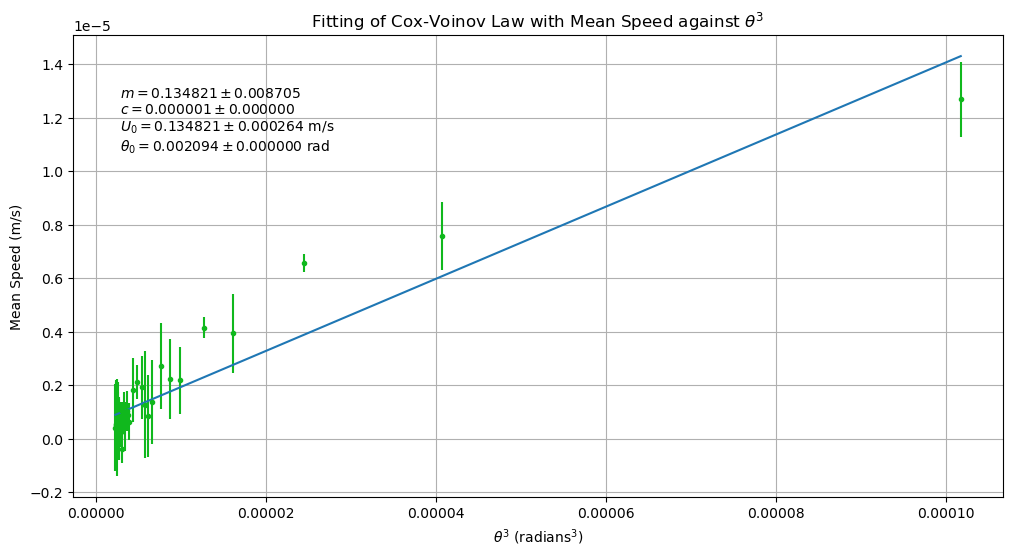

In [211]:
#Plotting 
plt.rcParams["figure.figsize"] = (12, 6)
plt.figure()
plt.errorbar(theta_cubed, speed_mean, yerr=speed_error, fmt='.', color="#10b81d")
plt.plot(theta_cubed, fit_m_cv * x_cv + fit_c_cv)

# Annotating plot with important values
textstr_cv = (
    r"$m = {:.6f} \pm {:.6f}$" "\n"
    r"$c = {:.6f} \pm {:.6f}$" "\n"
    r"$U_0 = {:.6f} \pm {:.6f}$ m/s" "\n"
    r"$\theta_0 = {:.6f} \pm {:.6f}$ rad"
).format(fit_m_cv, sigma_m_cv, fit_c_cv, sigma_c_cv, U_0_cv, U_0_error_cv, theta_0_cv, theta_0_error_cv)

plt.annotate(textstr_cv, xy=(0.05, 0.75), xycoords='axes fraction', fontsize=10)

plt.xlabel(r"$\theta^3$ ($\mathrm{radians}^3$)")
plt.ylabel("Mean Speed (m/s)")
plt.title(r"Fitting of Cox-Voinov Law with Mean Speed against $\theta^3$")
plt.grid()
plt.show()

Chi-Squared Value: 44.39328738979809
Reduced Chi-Squared: 3.338071409507227


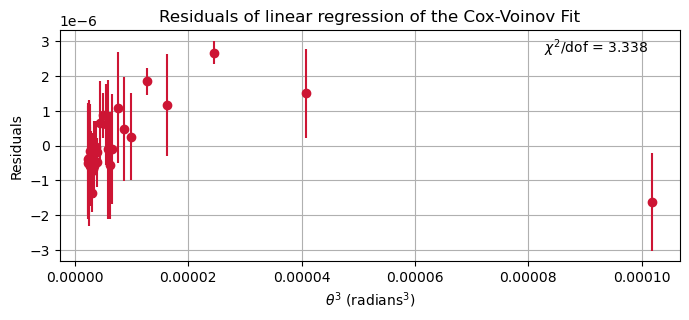

In [212]:
y_cv = speed_mean  # Renamed y to y_cv

# Perform fit using np.polyfit
fit_parameters_cv, fit_errors_cv = np.polyfit(x_cv, y_cv, 1, cov=True)
# Create set of fitted y values using fit parameters from np.polyfit, and original x values
y_fitted_cv = np.polyval(fit_parameters_cv, x_cv)

# Defining and calculating uncertainty
y_sigma_cv = speed_error
y_weights_cv = (1 / y_sigma_cv) * np.ones(np.size(y_cv))

# Create array of error values for the error bar plot below; each element is y_sigma
y_errors_cv = y_sigma_cv * np.ones(np.size(y_cv))

# Calculating Chi-Squared Fit
print(f"Chi-Squared Value: {chi_squared}")
dof_cv = len(y_cv) - len(fit_parameters_cv)
chi_squared_reduced_cv = chi_squared_cv / dof_cv
print(f"Reduced Chi-Squared: {chi_squared_reduced_cv}")

# Make plot of the residuals, using the 'errorbar' plotting 
plt.rcParams["figure.figsize"] = (8, 3)
plt.figure()
plt.errorbar(x_cv, y_cv - y_fitted_cv, yerr=y_errors_cv, fmt='o', color="#cd1534")
plt.xlabel(r"$\theta^3$ ($\mathrm{radians}^3$)")
plt.ylabel("Residuals")
plt.title("Residuals of linear regression of the Cox-Voinov Fit")

textstr_cv = r"$\chi^2$/dof = ${:.3f}$".format(chi_squared_reduced_cv)  # Annotation to display chi-squared fit on the plot

plt.annotate(textstr_cv, xy=(0.95, 0.90), xycoords='axes fraction', fontsize=10, ha='right')
plt.grid()
plt.show()

chi_squared_cv = np.sum(((y_cv - y_fitted_cv) / y_sigma_cv) ** 2)

Thus, the Cox-Voinov law fitted onto this dataset gives a reduced Chi Squared value of 3.338, showing that the fit is not suitable for the data. 

## Conclusion

Since the Reduced Chi Squared Value from the de Gennes fit was smaller than that of the Cox-Voinov fit, the de Gennes fit is more suitable for the data.